In [3]:
from matplotlib import pyplot as plt
import json

from pathlib import Path

import pandas as pd

import numpy as np 


from scipy.stats import sem

In [5]:
DIR = Path("../../artifacts/2023-08-s10/experiments/accuracy-basis-with-contamination")

In [45]:
def load(dataset, arch, layer, basis_name, contamination_level, training_size=1.0, logit_mod="oneclass", basis_mode="centered", seeds=[1]):
    
    arr_dfs = []
    for seed in seeds:
#         print(f"training-size={training_size}")
        with open(DIR / f"{dataset}--ts{training_size}-clv{contamination_level}-seed{seed}" / f"logit-mod-{logit_mod}" / arch / layer / f"{basis_name}--{basis_mode}" / "stats.json", "r") as fh:
            data = json.load(fh)
            
        
        df = pd.DataFrame(
            {
                "acc": data["arr_acc"],
                "k": data["arr_ks"],
            }
        )
        df["dims"] = data["dims"]

        # remark: the attribute name here is misnormzer. 
        # perhaps, we refactor it.
        df["original_acc"] = data["original_auroc"]
        df["seed"] = seed
            
        arr_dfs.append(df)
    
    df = pd.concat(arr_dfs).groupby(by="k").agg({
        "acc": ["mean", "std"],
        "seed": ["count"],
        "original_acc": ["first"],
        "dims": ["first"]
    })
    
    
    assert (df["seed"]["count"] == df["seed"]["count"].values[0]).all()

    for col in ["original_acc", "dims"]:

        assert (df[col]["first"] == df[col]["first"].values[0]).all()

    return df.reset_index()

load(
    dataset="cifar100-aquatic_mammals", 
    arch="cifar100-resnet18-wb15",
    layer="layer2", 
    basis_name="pca", 
    training_size=1.0,
    contamination_level=0.1
)[:5]


k    acc      seed original_acc  dims
       mean std count        first first
0  1  0.210 NaN     1        0.784   128
1  2  0.214 NaN     1        0.784   128
2  3  0.228 NaN     1        0.784   128
3  4  0.254 NaN     1        0.784   128
4  5  0.354 NaN     1        0.784   128

In [44]:
load(
    dataset="cifar100-aquatic_mammals", 
    arch="cifar100-resnet18-wb15",
    layer="layer2", 
    basis_name="pca", 
    training_size=1.0,
    contamination_level=0.5
)[:5]

k    acc      seed original_acc  dims
       mean std count        first first
0  1  0.212 NaN     1        0.784   128
1  2  0.206 NaN     1        0.784   128
2  3  0.228 NaN     1        0.784   128
3  4  0.256 NaN     1        0.784   128
4  5  0.352 NaN     1        0.784   128

In [11]:
!ls -la ../../artifacts/2023-08-s10/experiments/accuracy-basis-with-contamination/cifar100-aquatic_mammals--ts1.0-clv0.1-seed1

total 12
drwxr-xr-x 3 pat pat 4096 Aug 14 21:28 ./
drwxr-xr-x 7 pat pat 4096 Aug 14 21:28 ../
drwxr-xr-x 3 pat pat 4096 Aug 14 21:28 logit-mod-oneclass/


# Accuracy Basis Curve

## One Class Curve

In [29]:
def color(name):
    if "random" in name:
        return "lightgray"
    elif name in ["rel-abs", "rel-recon", "rel-reconnaive"]  or name in ["act-recon", "act-abs"]:
        return plt.gca().lines[-1].get_color()
    else:
        return None

def marker(name):
    if name in ["pca", "prca-abs", "prca-recon", 'rel-recon', "act-recon"]:
        return "."
    elif "pcaprca" in name:
        return "s"
    elif name in ["rel-reconnaive", "prca-reconnaive"]:
        return "|"
    else:
        return None
    
def ls(name):
    if "rel" in name or "act" in name:
        return "--"
    elif "random" in name:
        return ":"
    else:
        return "-"

In [30]:
CIFAR100_SUPERCLASSES = """
cifar100-aquatic_mammals
cifar100-fish
cifar100-flowers
cifar100-food_containers
cifar100-fruit_and_vegetables
cifar100-household_electrical_devices
cifar100-household_furniture
cifar100-insects
cifar100-large_carnivores
cifar100-large_man_made_outdoor_things
cifar100-large_natural_outdoor_scenes
cifar100-large_omnivores_and_herbivores
cifar100-medium_mammals
cifar100-non_insect_invertebrates
cifar100-people
cifar100-reptiles
cifar100-small_mammals
cifar100-trees
cifar100-vehicles_1
cifar100-vehicles_2
""".strip().split("\n")

CIFAR100_SUPERCLASSES

['cifar100-aquatic_mammals',
 'cifar100-fish',
 'cifar100-flowers',
 'cifar100-food_containers',
 'cifar100-fruit_and_vegetables',
 'cifar100-household_electrical_devices',
 'cifar100-household_furniture',
 'cifar100-insects',
 'cifar100-large_carnivores',
 'cifar100-large_man_made_outdoor_things',
 'cifar100-large_natural_outdoor_scenes',
 'cifar100-large_omnivores_and_herbivores',
 'cifar100-medium_mammals',
 'cifar100-non_insect_invertebrates',
 'cifar100-people',
 'cifar100-reptiles',
 'cifar100-small_mammals',
 'cifar100-trees',
 'cifar100-vehicles_1',
 'cifar100-vehicles_2']

## Accuracy Curve Aggregated Over Classes

In [31]:
def basis_displayname(basis_name):
    mapping = {
        "random": "Random",
        "act-recon": "Act",
        "rel-recon": "Rel",
        "pca": "PCA",
        'pcaprca-recon': "PRCA"
    }

    return f"{mapping.get(basis_name, basis_name):15s}"


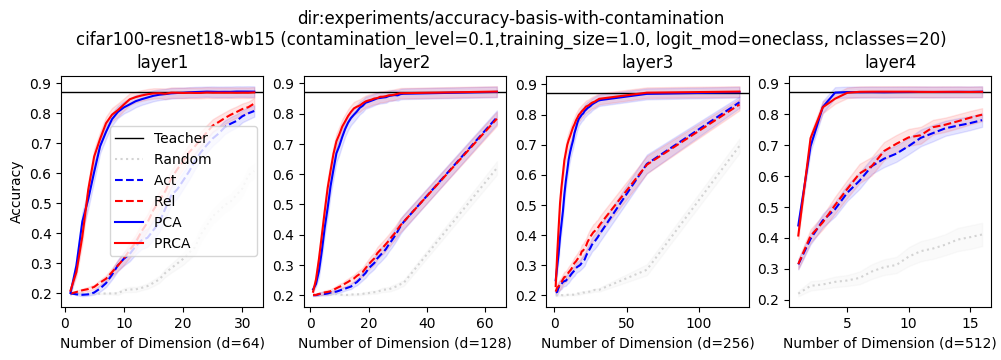

In [50]:
def accuracy_curve(
    arch, layers_and_factors,
    arr_classes=CIFAR100_SUPERCLASSES,
    arr_bases = [
        "random",
        "act-recon",
        "rel-recon",
        "pca",
        "pcaprca-recon",
    ],
    logit_mod="oneclass",
    training_size=1.0,
    contamination_level=0.1
):

        
    ncols = len(layers_and_factors)
    
    plt.figure(figsize=(ncols * 3, 3))
    plt.suptitle("\n".join([
        "dir:" + "/".join(f"{DIR}".split("/")[-2:]),
        f"{arch} (contamination_level={contamination_level},training_size={training_size}, logit_mod={logit_mod}, nclasses={len(arr_classes)})"
    ]), y=1.1)
    
    def color(basis_name):
        if basis_name in ["act-recon", "pca"]:
            return "blue"
        elif basis_name in ["rel-recon", "pcaprca-recon"]:
            return "red"
        elif "random" == basis_name:
            return "lightgray"
        else:
            return "green"
            raise NotImplementedError(f"no color for `{basis_name}`")
            
    def ls(basis_name):
        if basis_name == "random":
            return ":"
        elif basis_name in ["act-recon", "rel-recon"]:
            return "--"
        else:
            return "-"
        
    
    for lix, (layer, factor) in enumerate(layers_and_factors):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer)

        teacher_stats = []
        for dataset in arr_classes:
            df = load(
                dataset=dataset,  arch=arch, layer=layer,  basis_name="random",  training_size=training_size,
                logit_mod=logit_mod,
                contamination_level=contamination_level,
            )
            acc = df["original_acc"]["first"].values
            np.testing.assert_equal(acc[0], acc)
            teacher_stats.append(acc[0])
        
        mean_teacher = np.mean(teacher_stats)
        stderr_teacher = sem(teacher_stats)

        assert mean_teacher.shape == stderr_teacher.shape == ()

        plt.axhline(mean_teacher, label="Teacher", color="k", lw=1, ls="-")

        for basis_name in arr_bases:
            stats = []
            for dataset in arr_classes:
                df = load(
                    dataset=dataset, 
                    arch=arch,
                    layer=layer, 
                    basis_name=basis_name, 
                    training_size=training_size,
                    logit_mod=logit_mod,
                    contamination_level=contamination_level
                )
                    
                    
                d = df["dims"]["first"].values[0]
                stats.append(df["acc"]["mean"].values)
                k = df["k"].values
            
            stats = np.array(stats)
            
            selected = k <= d//factor
            
            assert stats.shape == (len(arr_classes), len(k))
            
            mean_stats = np.mean(stats, axis=0)
            stderr_stats = sem(stats, axis=0)
            assert stderr_stats.shape == mean_stats.shape
#             print(stats.shape)

            _k = k[selected]
            _mean = mean_stats[selected]
            _stderr = stderr_stats[selected]
            plt.plot(
                _k,
                _mean, 
                label=basis_displayname(basis_name),
                color=color(basis_name),
                ls=ls(basis_name)
            )
    
            plt.fill_between(
                _k,
                _mean - _stderr,
                _mean + _stderr,
                color=plt.gca().lines[-1].get_color(),
                alpha=0.1
            )
                                
            
            
            
        plt.xlabel(f"Number of Dimension (d={d})")
        if lix == 0:
            plt.ylabel("Accuracy")
            plt.legend()

            
accuracy_curve(
    arch="cifar100-resnet18-wb15",
    layers_and_factors = [
        ("layer1", 2),
        ("layer2", 2),
        ("layer3", 2),
        ("layer4", 32)
    ],
    contamination_level=0.1,
)

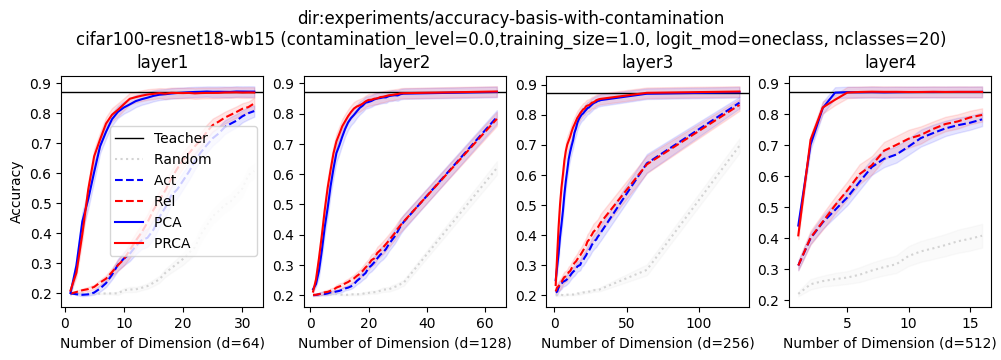

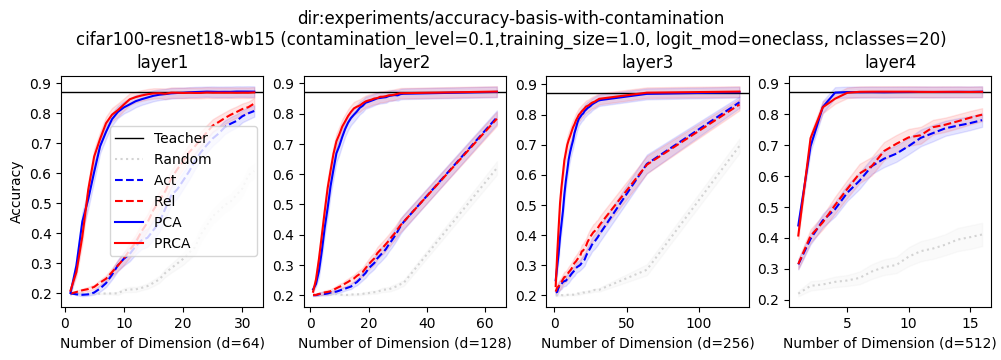

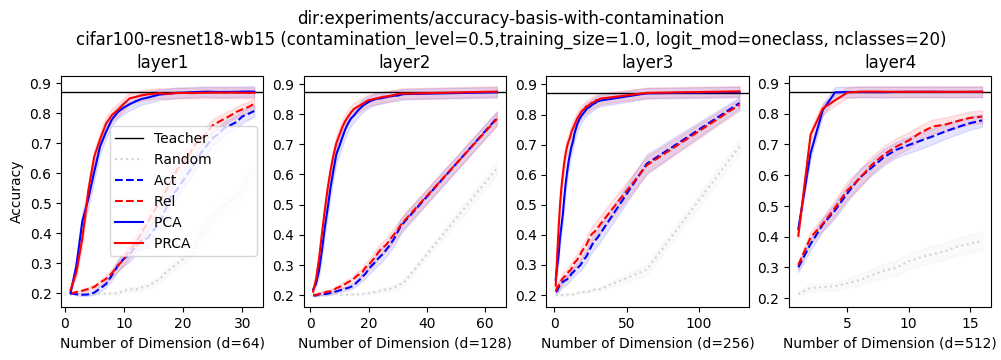

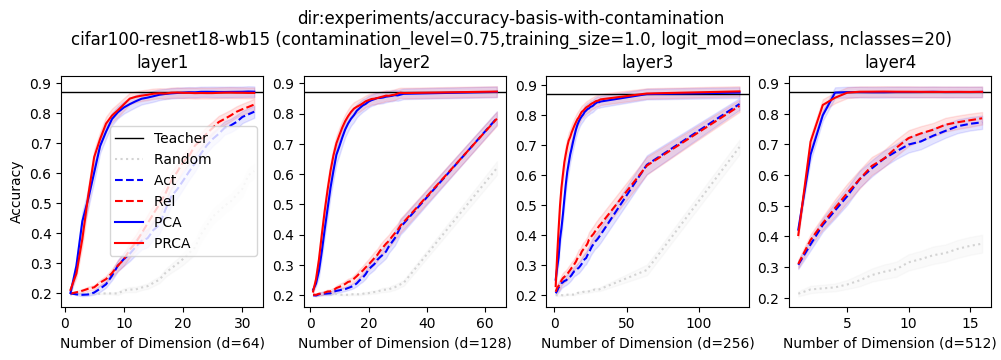

In [56]:
for level in [0.0, 0.1, 0.5, 0.75]:
    accuracy_curve(
        arch="cifar100-resnet18-wb15",
        layers_and_factors = [
            ("layer1", 2),
            ("layer2", 2),
            ("layer3", 2),
            ("layer4", 32)
        ],
        contamination_level=level,
    )

**Goal**: comparison between contamination levels = {0.0, 0.1, 0.5, 0.75}

**Hypothesis**: as contamination level increases *implies* Perf(PRCA) - Perf(PCA) is large

**Conclusion**: No, this doesn't seem to be the case. Partly, it might be due to the fact that the contamination we have is very local, one specific location and one class that the contamating symbol has. 

---

Job:
- contamination-level=0.1 (347053)
- contamination-level=0.0 (347067)
- contamination-level=0.5 (347066)
- contamination-level=0.75 (347069)
